# DIPm-TV — Real EELS data: $\mathrm{Fe}_x\mathrm{O}_y$ nanocubes

Two-channel EELS reconstruction: **Fe₃O₄** (channel 0) and **FeO** (channel 1).  
Limited tilt: 9 projections over ±70°.  
Volume convention: **(X, Z, Y)** — X = detector cols / depth (axis 0), Z = beam at 0° / MW elongation (axis 1), Y = tilt axis (axis 2).

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from tifffile import imread

import sys
sys.path.insert(0, '../../Src')
from radon import Radon3D
from dipm_tv import CNN3D, run_dipm_tv, preprocess_sinograms, save_results
from utils import norm_percentile, make_rgb_overlay

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA L40


In [3]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
FULL_PATH = Path().resolve().parents[1] / 'Data' / 'EELS_data'
PHASE_NAMES = ['Fe3O4', 'FeO']
SAMPLE      = 'Fe nanocubes'
OUT_DIR     = Path('results') / SAMPLE

# ---------------------------------------------------------------------------
# Acquisition conditions (angles)
# ---------------------------------------------------------------------------
THETA = np.array([-69.5, -52.5, -35.0, -17.5, 0.0, 17.5, 35.0, 52.5, 70.0])

# ---------------------------------------------------------------------------
# DIPm-TV hyperparameters
# ---------------------------------------------------------------------------
NUM_ITER     = 250
INPUT_DEPTH  = 32
LR           = 5e-4
NOISE_REG    = 0.1
STD_INP_NOISE = 1.0
EXP_WEIGHT   = 0.99
LAMBDA_TV    = 1e-9
LOSS_TYPE    = 'L1'
USE_AMP      = False
SAVE_EVERY   = 100
UD_FILTERS   = [32, 64, 64, 128]
SKIP_FILTERS = [8,  16, 16,  32]

SIRT_ITERS   = 50
PLOT_EVERY   = 25

# ---------------------------------------------------------------------------
# Per-channel colormaps  (match overlay: Fe3O4 → magenta, FeO → green)
# ---------------------------------------------------------------------------
CMAPS = [
    LinearSegmentedColormap.from_list('fe3', ['black', 'magenta']),  # Fe3O4
    LinearSegmentedColormap.from_list('feo', ['black',  'lime']),    # FeO
]

## Load and preprocess data

In [4]:
# Load preprocessed projections — shape (N_angles, depth, img_size) per channel
data = np.stack([
    imread(str(FULL_PATH / f'{name}_proj.tif')) for name in PHASE_NAMES
]).astype(np.float32)
print(f'Loaded shape : {data.shape}  [N_ch, N_angles, depth, img_size]')

DEPTH    = data.shape[2]
IMG_SIZE = data.shape[3]
print(f'DEPTH={DEPTH}, IMG_SIZE={IMG_SIZE}')

N_CH, N_ANGLES = data.shape[:2]

# Radon projector
rad_op = Radon3D(angle=np.deg2rad(THETA), depth=DEPTH, size=IMG_SIZE)

# Normalise per-channel + rearrange to (N_ch, depth, N_angles, img_size)
sino_torch, x_min, x_max = preprocess_sinograms(data, THETA, device=DEVICE)
print(f'sino_torch   : {sino_torch.shape}  [N_ch, depth=X, N_angles, size=H]')
print(f'x_min={x_min}, x_max={x_max}')

Loaded shape : (2, 9, 112, 112)  [N_ch, N_angles, depth, img_size]
DEPTH=112, IMG_SIZE=112
sino_torch   : torch.Size([2, 112, 9, 112])  [N_ch, depth=X, N_angles, size=H]
x_min=[0. 0.], x_max=[3.5635903e-06 2.8045170e-06]


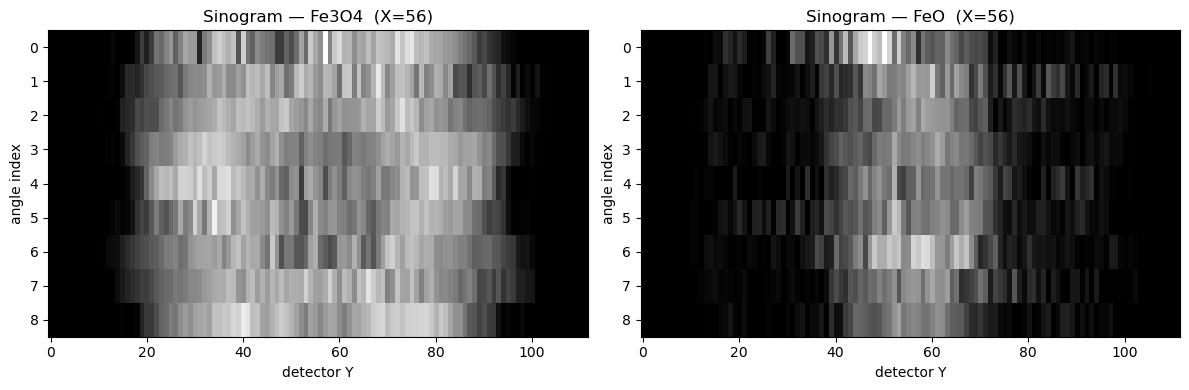

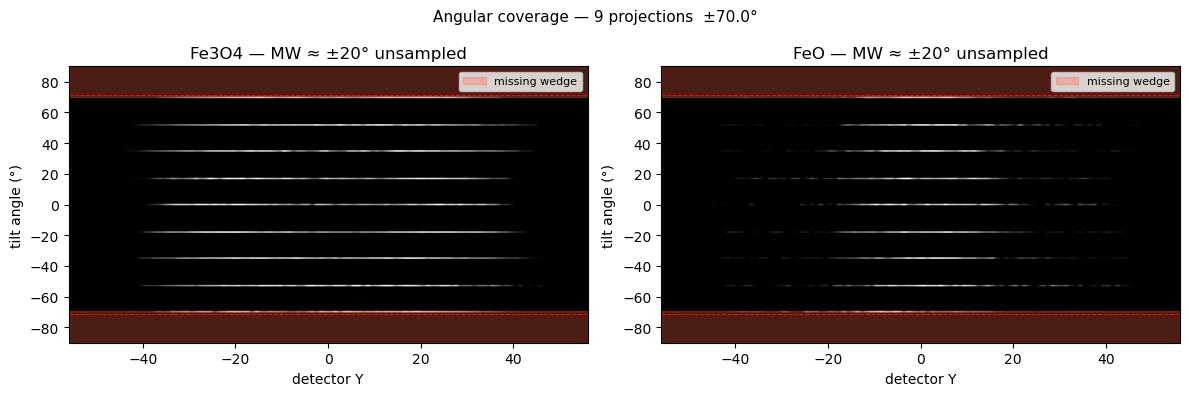

In [5]:
# Sinogram at mid depth
fig, axes = plt.subplots(1, N_CH, figsize=(6 * N_CH, 4))
for i, (ax, name) in enumerate(zip(axes, PHASE_NAMES)):
    sl = sino_torch[i, DEPTH // 2].detach().cpu().numpy()
    ax.imshow(sl, aspect='auto', cmap='gray')
    ax.set_title(f'Sinogram — {name}  (X={DEPTH//2})')
    ax.set_xlabel('detector Y')
    ax.set_ylabel('angle index')
plt.tight_layout()
plt.show()

# Missing-wedge coverage map
ang_axis = np.linspace(-90, 90, 181)
fig2, axes2 = plt.subplots(1, N_CH, figsize=(6 * N_CH, 4))
for i, (ax, name) in enumerate(zip(axes2, PHASE_NAMES)):
    sl = sino_torch[i, DEPTH // 2].detach().cpu().numpy()
    full_sino = np.zeros((len(ang_axis), IMG_SIZE), dtype=np.float32)
    for j, theta in enumerate(THETA):
        idx = np.argmin(np.abs(ang_axis - theta))
        row = sl[j]
        full_sino[idx] = norm_percentile(row)
    ax.imshow(full_sino, aspect='auto', cmap='gray', origin='lower',
              extent=[-IMG_SIZE // 2, IMG_SIZE // 2, -90, 90], vmin=0, vmax=1)
    ax.axhspan(-90,       THETA[0],  alpha=0.3, color='tomato', label='missing wedge')
    ax.axhspan(THETA[-1], 90,        alpha=0.3, color='tomato')
    ax.axhline(THETA[0]-1.5,  color='red', lw=0.75, ls='--')
    ax.axhline(THETA[-1]+1.5, color='red', lw=0.75, ls='--')
    ax.set_title(f'{name} — MW ≈ ±{90 - np.abs(THETA).max():.0f}° unsampled')
    ax.set_xlabel('detector Y')
    ax.set_ylabel('tilt angle (°)')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(
    f'Angular coverage — {len(THETA)} projections  ±{np.abs(THETA).max():.1f}°',
    fontsize=11)
plt.tight_layout()
plt.show()

## SIRT reconstruction

In [6]:
sirt_list = []
for i in range(N_CH):
    vol = torch.squeeze(
        rad_op.backward_sirt_ts(
            sino_torch[i],      # (depth, N_angles, img_size)
            progress_bar=True,
            num_iters=SIRT_ITERS,
        )
    ).detach().cpu().numpy()    # (depth, img_size, img_size)
    # denormalise
    vol = vol * (x_max[i] - x_min[i]) + x_min[i]
    sirt_list.append(vol)
    print(f'SIRT {PHASE_NAMES[i]}  min={vol.min():.4f}  max={vol.max():.4f}')

100%|██████████| 50/50 [00:00<00:00, 86.86it/s]


SIRT Fe3O4  min=0.0000  max=0.0000


100%|██████████| 50/50 [00:00<00:00, 83.10it/s]

SIRT FeO  min=0.0000  max=0.0000


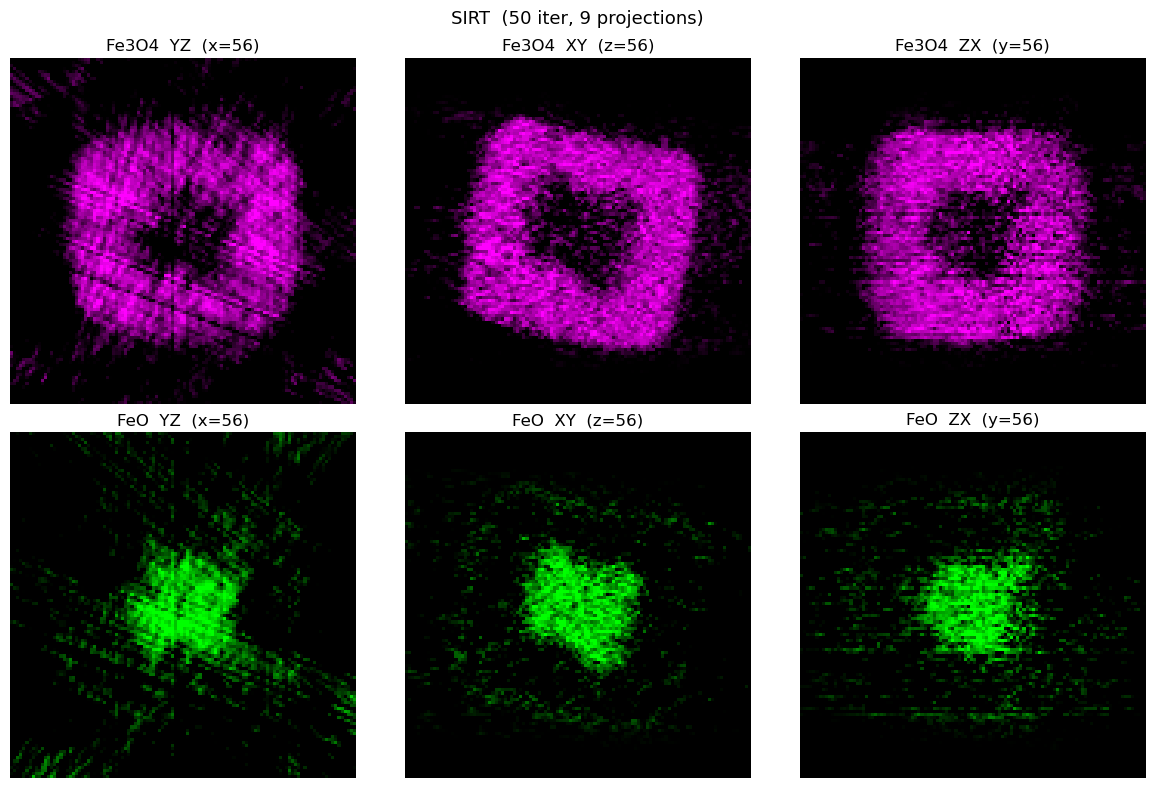

In [7]:
fig, axes = plt.subplots(N_CH, 3, figsize=(12, 4 * N_CH))
for i, name in enumerate(PHASE_NAMES):
    vol = sirt_list[i]   # (X, Z, Y)
    axes[i, 0].imshow(norm_percentile(vol[DEPTH // 2, :, :]), cmap=CMAPS[i])
    axes[i, 0].set_title(f'{name}  YZ  (x={DEPTH//2})')
    axes[i, 1].imshow(norm_percentile(vol[:, IMG_SIZE // 2, :]), cmap=CMAPS[i])
    axes[i, 1].set_title(f'{name}  XY  (z={IMG_SIZE//2})')
    axes[i, 2].imshow(norm_percentile(vol[:, :, IMG_SIZE // 2]), cmap=CMAPS[i])
    axes[i, 2].set_title(f'{name}  ZX  (y={IMG_SIZE//2})')
    for ax in axes[i]: ax.axis('off')
plt.suptitle(f'SIRT  ({SIRT_ITERS} iter, {len(THETA)} projections)', fontsize=13)
plt.tight_layout()
plt.show()

## DIPm-TV reconstruction

In [8]:
net = CNN3D(
    nbr          = N_CH,
    input_shape  = INPUT_DEPTH,
    down_filters = UD_FILTERS,
    up_filters   = UD_FILTERS,
    skip_filters = SKIP_FILTERS,
).to(DEVICE)

Output / Input img size : torch.Size([1, 32, 112, 112, 112])
network parameters: 2_156_922
image size : 2_809_856


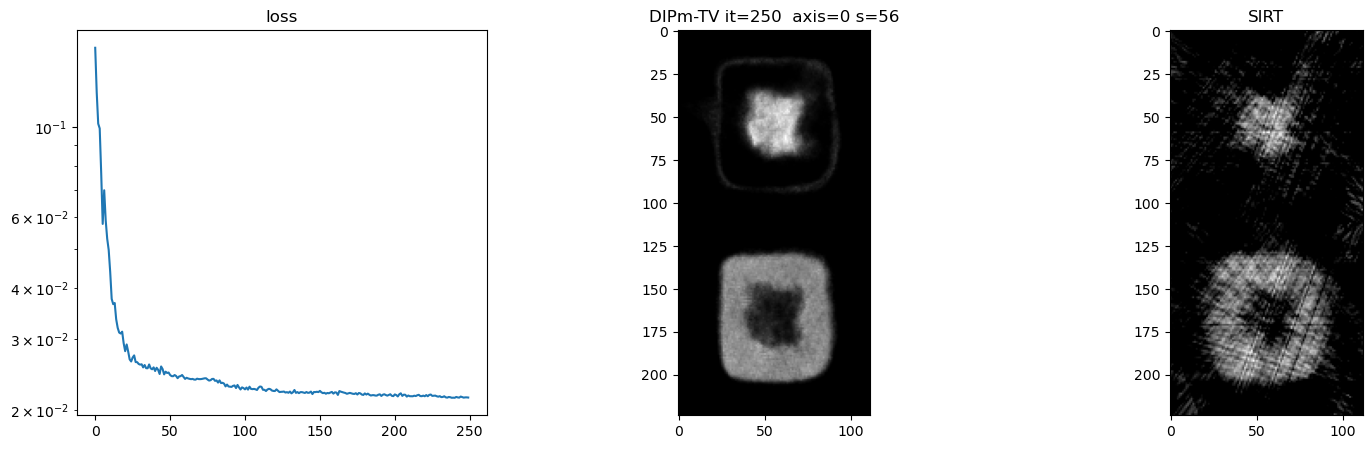

DIP-MTV: 100%|██████████| 250/250 [01:01<00:00,  4.06it/s]

Total time: 0:01:01.597875


In [9]:
iter_out, loss_vals = run_dipm_tv(
    net,
    rad_op,
    sino_torch,
    sirt_vol    = np.stack(sirt_list),   # (N_ch, depth, img_size, img_size)
    num_iter    = NUM_ITER,
    input_depth = INPUT_DEPTH,
    depth       = DEPTH,
    img_size    = IMG_SIZE,
    lr          = LR,
    noise_reg   = NOISE_REG,
    exp_weight  = EXP_WEIGHT,
    lambda_tv   = LAMBDA_TV,
    loss_type   = LOSS_TYPE,
    std_inp_noise = STD_INP_NOISE,
    plot_every  = PLOT_EVERY,
    plot_slice  = DEPTH // 2,
    plot_axis   = 0,
    save_every  = SAVE_EVERY,
    use_amp     = USE_AMP,
    device      = DEVICE,
)

## Results

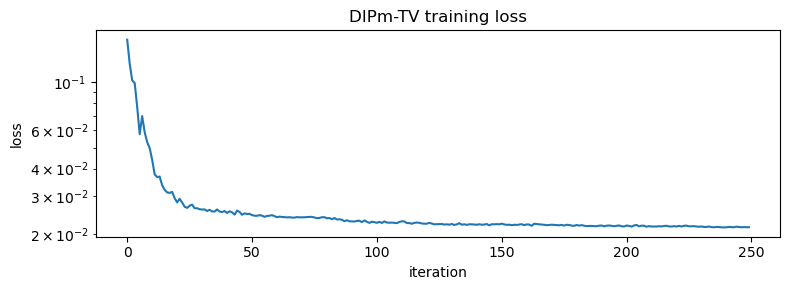

In [10]:
plt.figure(figsize=(8, 3))
plt.semilogy(loss_vals)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('DIPm-TV training loss')
plt.tight_layout()
plt.show()

In [11]:
# Denormalise final reconstruction
rec_norm = iter_out[-1][1] # (N_ch, depth, img_size, img_size)
rec = rec_norm.copy()
for i in range(N_CH):
    rec[i] = rec[i] * (x_max[i] - x_min[i]) + x_min[i]

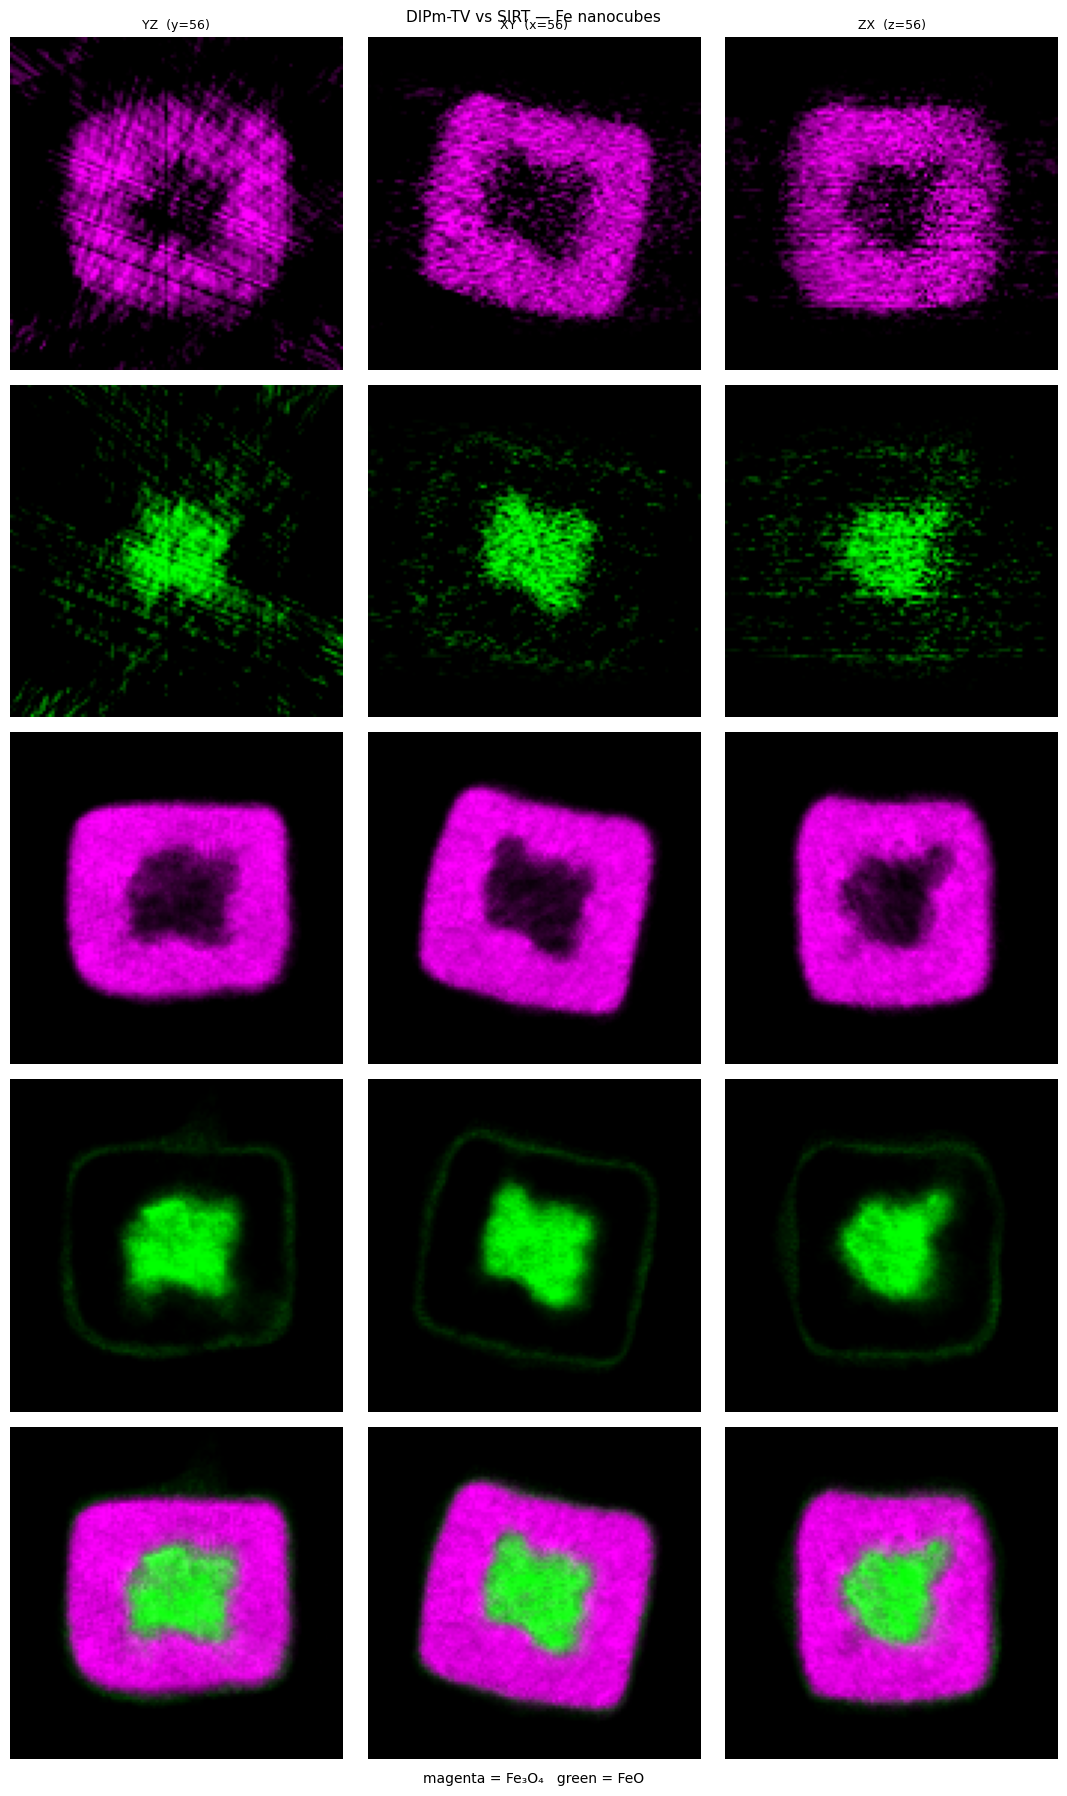

In [12]:
SL_0 = DEPTH    // 2
SL_1 = IMG_SIZE // 2
SL_2 = IMG_SIZE // 2

slices_def = [
    (lambda v: v[SL_0, :, :],  f'YZ  (y={SL_0})'),
    (lambda v: v[:, SL_1, :],  f'XY  (x={SL_1})'),
    (lambda v: v[:, :, SL_2],  f'ZX  (z={SL_2})'),
]

rows_def = [
    ('SIRT Fe3O4',    sirt_list[0], CMAPS[0]),
    ('SIRT FeO',      sirt_list[1], CMAPS[1]),
    ('DIPm-TV Fe3O4', rec[0],       CMAPS[0]),
    ('DIPm-TV FeO',   rec[1],       CMAPS[1]),
    ('overlay',       None,          None),
]

fig, axes = plt.subplots(5, 3, figsize=(11, 18))

for col, (sl_fn, sl_lbl) in enumerate(slices_def):
    for row, (lbl, vol, cmap) in enumerate(rows_def):
        ax = axes[row, col]
        if vol is None:
            # Fe3O4 → magenta (R+B), FeO → green (G)
            ax.imshow(make_rgb_overlay(sl_fn(rec[0]), sl_fn(rec[1]), sl_fn(rec[0])))
        else:
            ax.imshow(norm_percentile(sl_fn(vol)), cmap=cmap, vmin=0, vmax=1)
        if row == 0:
            ax.set_title(sl_lbl, fontsize=9)
        ax.set_ylabel(lbl, fontsize=8)
        ax.axis('off')

fig.text(0.5, -0.005, 'magenta = Fe₃O₄   green = FeO', ha='center', fontsize=10)
plt.suptitle(f'DIPm-TV vs SIRT — {SAMPLE}', fontsize=11)
plt.tight_layout()
plt.show()

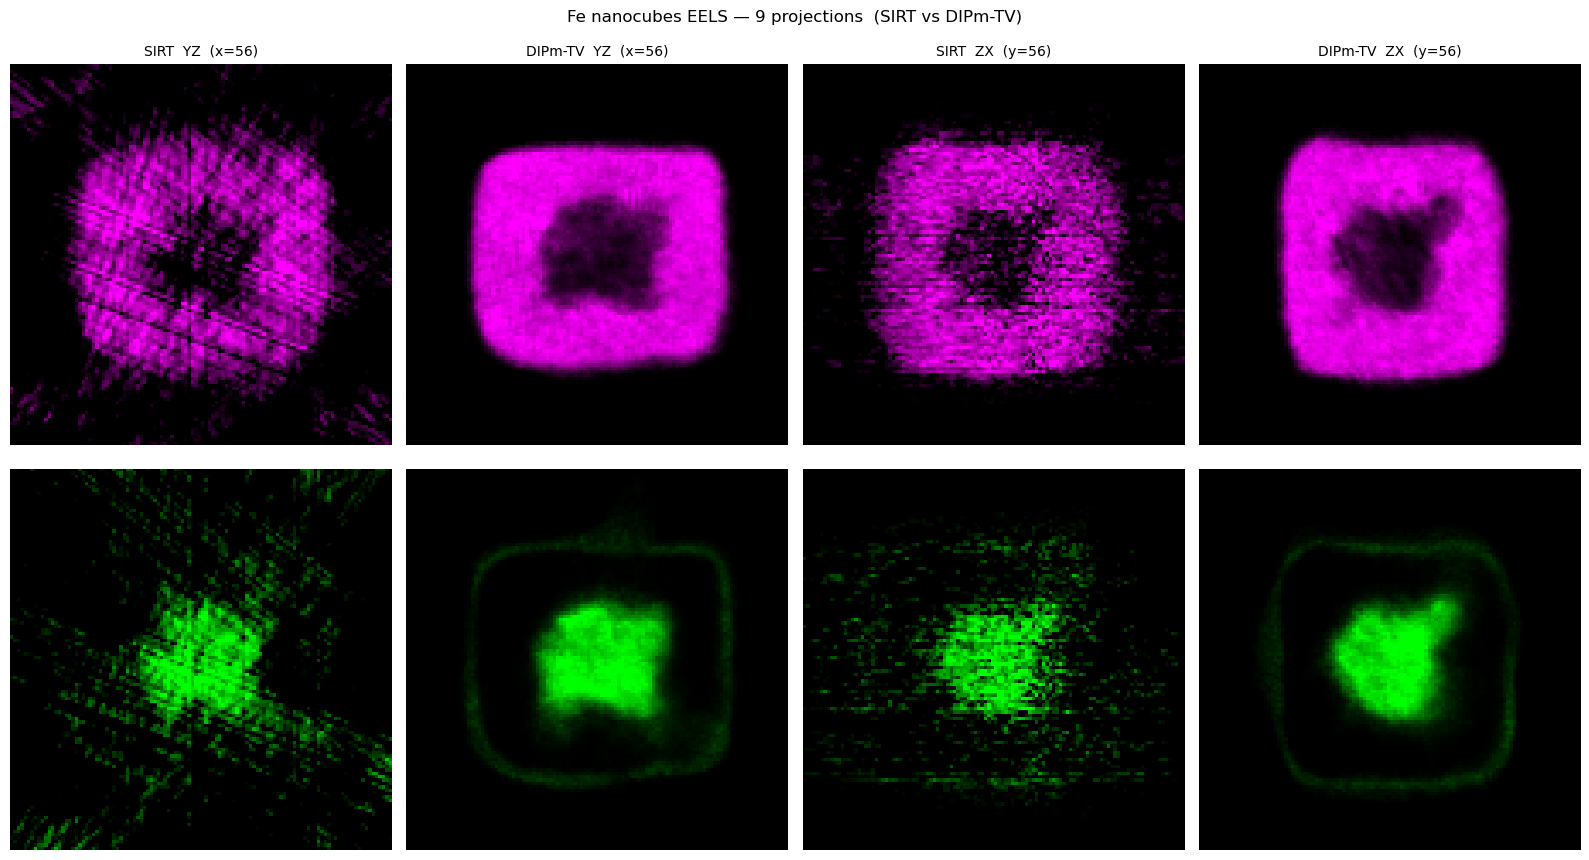

In [13]:
PLOT_X = DEPTH    // 2
PLOT_Y = IMG_SIZE // 2

fig, axes = plt.subplots(N_CH, 4, figsize=(16, 4.5 * N_CH))
col_titles = [
    f'SIRT  YZ  (x={PLOT_X})', f'DIPm-TV  YZ  (x={PLOT_X})',
    f'SIRT  ZX  (y={PLOT_Y})', f'DIPm-TV  ZX  (y={PLOT_Y})',
]
for j, ct in enumerate(col_titles):
    axes[0, j].set_title(ct, fontsize=10)

for i, name in enumerate(PHASE_NAMES):
    sv, dv = sirt_list[i], rec[i]
    for j, sl in enumerate([
        norm_percentile(sv[PLOT_X, :, :]), norm_percentile(dv[PLOT_X, :, :]),
        norm_percentile(sv[:, :, PLOT_Y]), norm_percentile(dv[:, :, PLOT_Y]),
    ]):
        axes[i, j].imshow(sl, cmap=CMAPS[i], vmin=0, vmax=1)
        axes[i, j].set_ylabel(name, fontsize=10)
        axes[i, j].axis('off')

plt.suptitle(f'Fe nanocubes EELS — {len(THETA)} projections  (SIRT vs DIPm-TV)', fontsize=12)
plt.tight_layout()
plt.show()

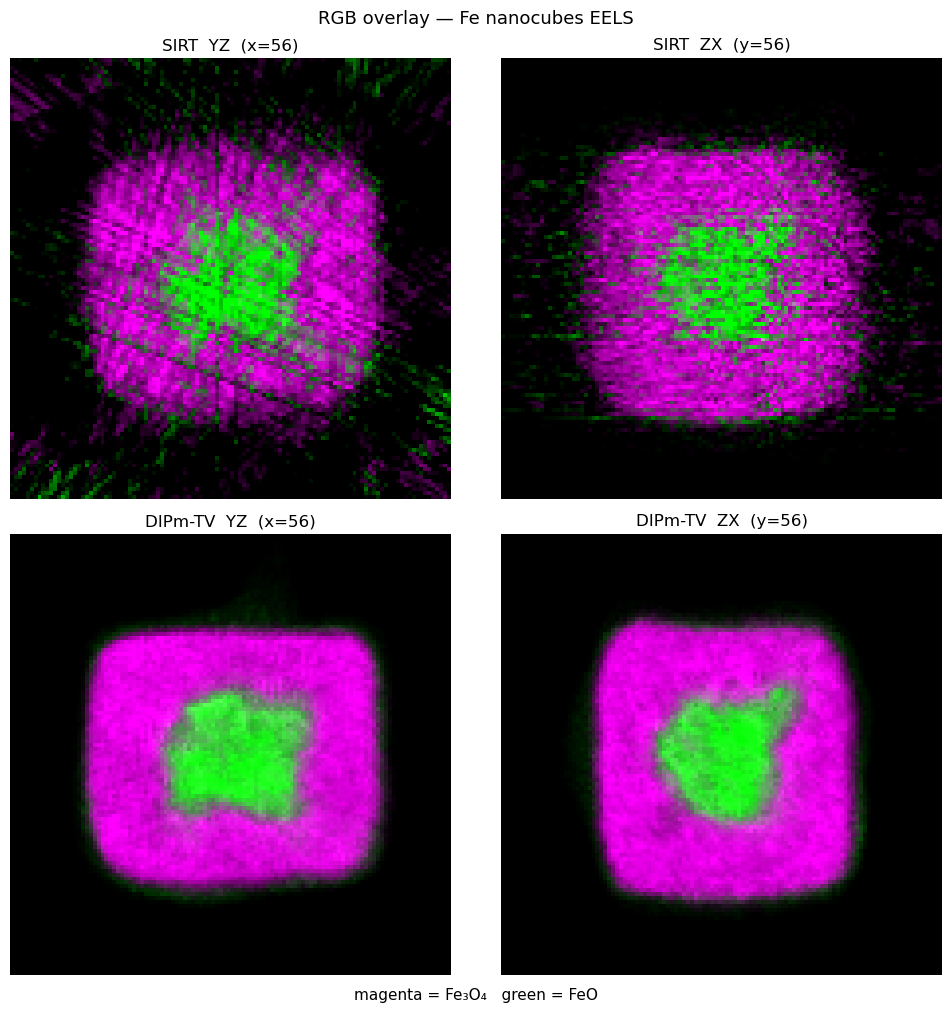

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for row, (vols, method) in enumerate([
    (sirt_list,        'SIRT'),
    ([rec[0], rec[1]], 'DIPm-TV'),
]):
    v0, v1 = vols[0], vols[1]
    for col, (sl_fn, sl_lbl) in enumerate([
        (lambda v: v[PLOT_X, :, :], f'YZ  (x={PLOT_X})'),
        (lambda v: v[:, :, PLOT_Y], f'ZX  (y={PLOT_Y})'),
    ]):
        # Fe3O4 → magenta (R+B), FeO → green (G)
        axes[row, col].imshow(make_rgb_overlay(sl_fn(v0), sl_fn(v1), sl_fn(v0)))
        axes[row, col].set_title(f'{method}  {sl_lbl}')
        axes[row, col].axis('off')

fig.text(0.5, -0.01, 'magenta = Fe₃O₄   green = FeO', ha='center', fontsize=11)
plt.suptitle('RGB overlay — Fe nanocubes EELS', fontsize=13)
plt.tight_layout()
plt.show()

## Save results

In [15]:
save_results(
    iter_out,
    phase_names = PHASE_NAMES,
    out_dir     = OUT_DIR,
    x_min       = x_min,
    x_max       = x_max,
    sample      = SAMPLE,
    lambda_tv   = LAMBDA_TV,
    lr          = LR,
    noise_reg   = NOISE_REG,
    loss_type   = LOSS_TYPE,
)
print(f'Saved to {OUT_DIR}')

Saved: results\Fe nanocubes\DIP_recon_Fe nanocubes_Fe3O4_it249_tv1e-09_lr0.0005_nr0.1_L1.tif  shape(Z,Y,X)=(112, 112, 112)
Saved: results\Fe nanocubes\DIP_recon_Fe nanocubes_FeO_it249_tv1e-09_lr0.0005_nr0.1_L1.tif  shape(Z,Y,X)=(112, 112, 112)
Saved to results\Fe nanocubes
